<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Redes_GAN_N%C3%BAmeros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# GAN - Generación de imágenes con MNIST
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

BATCH_SIZE = 128
LATENT_SIZE = 100
EPOCHS = 30
LR = 0.0002

# ------------------------------------------------------------
# 2. Dataset MNIST
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# ------------------------------------------------------------
# 3. GENERADOR
# ------------------------------------------------------------

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(LATENT_SIZE, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 28 * 28),

            nn.Tanh()
        )

    def forward(self, z):

        imagen = self.model(z)

        return imagen.view(-1, 1, 28, 28)


# ------------------------------------------------------------
# 4. DISCRIMINADOR
# ------------------------------------------------------------

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        return self.model(x)


# ------------------------------------------------------------
# 5. Crear redes
# ------------------------------------------------------------

G = Generator().to(device)
D = Discriminator().to(device)

print(G)
print(D)

# ------------------------------------------------------------
# 6. Función de pérdida y optimizadores
# ------------------------------------------------------------

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=LR,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=LR,
    betas=(0.5, 0.999)
)

# ------------------------------------------------------------
# 7. Entrenamiento
# ------------------------------------------------------------

for epoch in range(EPOCHS):

    for batch_idx, (real_images, _) in enumerate(loader):

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        # -----------------------------------------------
        # Etiquetas
        # -----------------------------------------------

        real_labels = torch.ones(
            batch_size,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size,
            1,
            device=device
        )

        # =================================================
        # ENTRENAR DISCRIMINADOR
        # =================================================

        optimizer_D.zero_grad()

        # Imágenes reales

        output_real = D(real_images)

        loss_real = criterion(
            output_real,
            real_labels
        )

        # Imágenes falsas

        noise = torch.randn(
            batch_size,
            LATENT_SIZE,
            device=device
        )

        fake_images = G(noise)

        output_fake = D(
            fake_images.detach()
        )

        loss_fake = criterion(
            output_fake,
            fake_labels
        )

        # Pérdida total

        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()

        # =================================================
        # ENTRENAR GENERADOR
        # =================================================

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_SIZE,
            device=device
        )

        fake_images = G(noise)

        output = D(fake_images)

        # El generador quiere que el discriminador
        # piense que sus imágenes son reales

        loss_G = criterion(
            output,
            real_labels
        )

        loss_G.backward()

        optimizer_G.step()

    # ----------------------------------------------------
    # Mostrar progreso
    # ----------------------------------------------------

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Loss D: {loss_D.item():.4f} "
        f"Loss G: {loss_G.item():.4f}"
    )

Dispositivo: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.73MB/s]


Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=1024, bias=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=512, out_features=256, bias=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)
Epoch [1/30] Loss D: 0.7716 

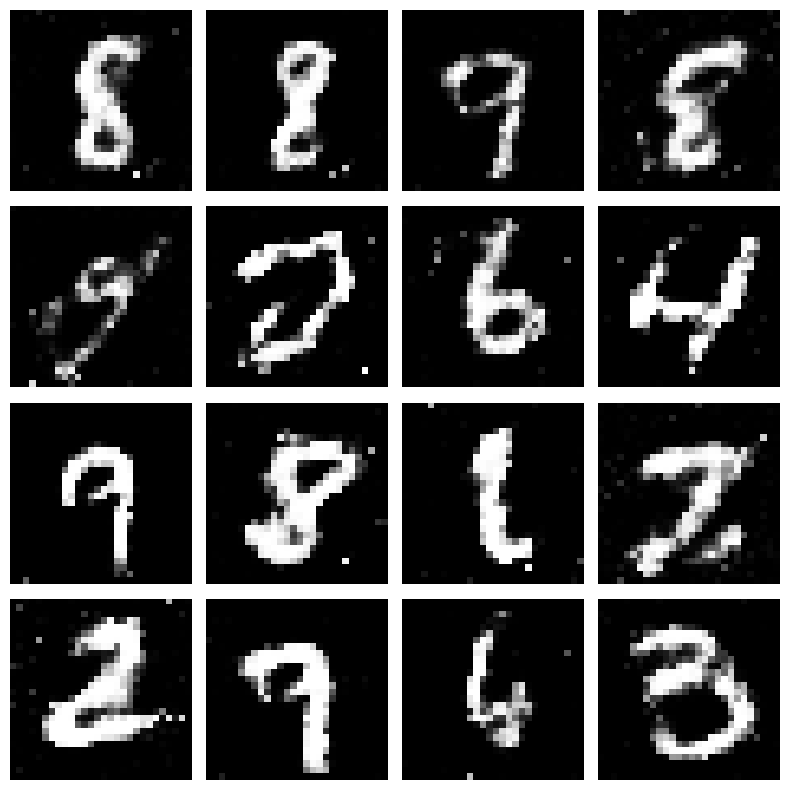

In [2]:
# ============================================================
# GENERAR IMÁGENES
# ============================================================

G.eval()

with torch.no_grad():

    noise = torch.randn(
        16,
        LATENT_SIZE,
        device=device
    )

    generated = G(noise)

G.train()

# Llevar valores de [-1,1] a [0,1]

generated = (generated + 1) / 2

fig, axes = plt.subplots(
    4,
    4,
    figsize=(8, 8)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        generated[i].cpu().squeeze(),
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

Dispositivo: cuda

GENERADOR
Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

DISCRIMINADOR
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Época [1/100] Loss D: 1.0992 Loss G: 1.4374


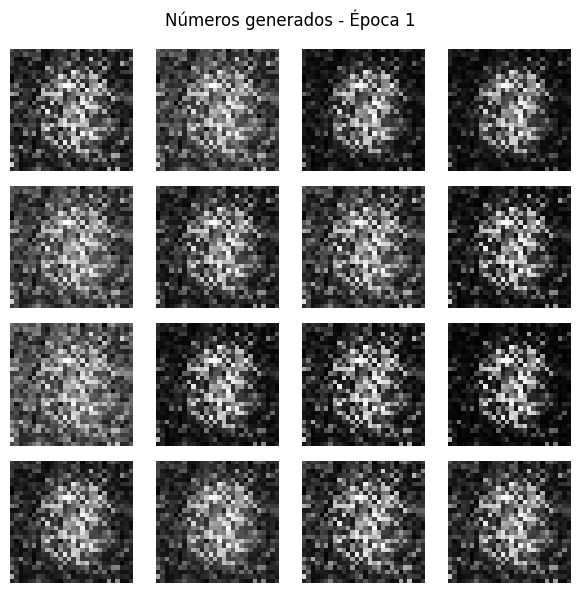

Época [2/100] Loss D: 1.0668 Loss G: 1.1744
Época [3/100] Loss D: 0.8245 Loss G: 1.7015
Época [4/100] Loss D: 0.8999 Loss G: 2.0719
Época [5/100] Loss D: 1.1038 Loss G: 1.0475
Época [6/100] Loss D: 0.9895 Loss G: 2.3246
Época [7/100] Loss D: 0.5979 Loss G: 1.8221
Época [8/100] Loss D: 0.8712 Loss G: 1.3942
Época [9/100] Loss D: 1.2217 Loss G: 2.7239
Época [10/100] Loss D: 1.1802 Loss G: 0.6481


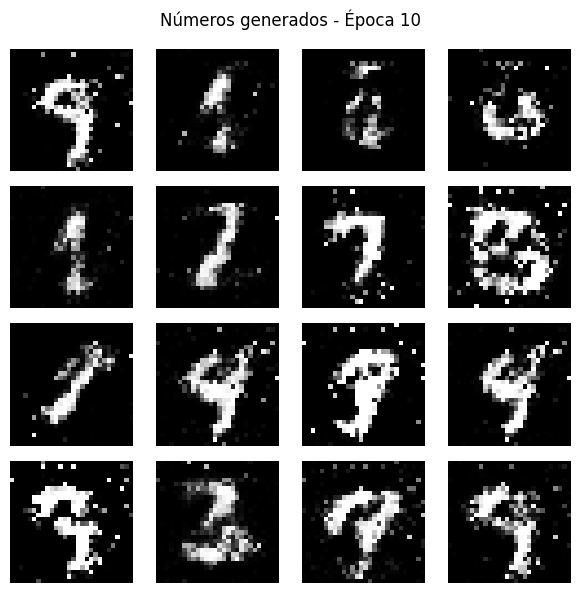

Época [11/100] Loss D: 1.0453 Loss G: 0.8030
Época [12/100] Loss D: 1.1231 Loss G: 0.7294
Época [13/100] Loss D: 1.0566 Loss G: 0.9776
Época [14/100] Loss D: 1.2840 Loss G: 1.8890
Época [15/100] Loss D: 1.0375 Loss G: 0.9615
Época [16/100] Loss D: 1.1111 Loss G: 1.2287
Época [17/100] Loss D: 1.1208 Loss G: 1.1474
Época [18/100] Loss D: 1.1165 Loss G: 1.0930
Época [19/100] Loss D: 1.3524 Loss G: 1.7514
Época [20/100] Loss D: 1.2400 Loss G: 1.2540


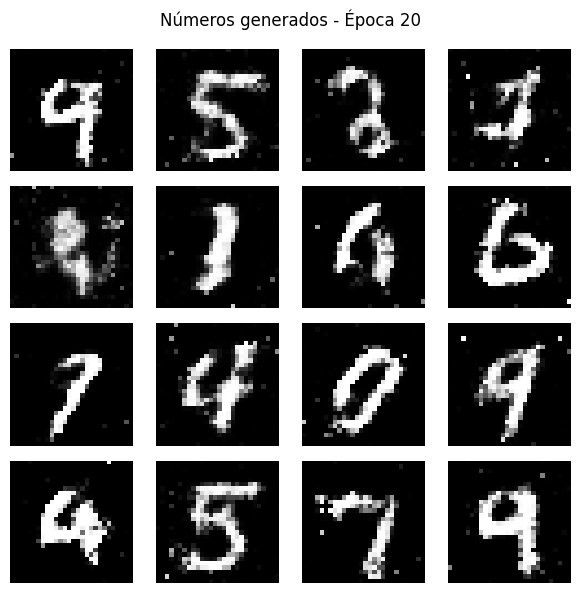

Época [21/100] Loss D: 1.1536 Loss G: 1.0047
Época [22/100] Loss D: 1.1371 Loss G: 1.1157
Época [23/100] Loss D: 1.1732 Loss G: 0.7936
Época [24/100] Loss D: 1.1801 Loss G: 1.4713
Época [25/100] Loss D: 1.2694 Loss G: 1.5039
Época [26/100] Loss D: 1.2228 Loss G: 0.9804
Época [27/100] Loss D: 1.1155 Loss G: 0.9825
Época [28/100] Loss D: 1.2206 Loss G: 1.2363
Época [29/100] Loss D: 1.0296 Loss G: 1.0570
Época [30/100] Loss D: 1.2476 Loss G: 1.2192


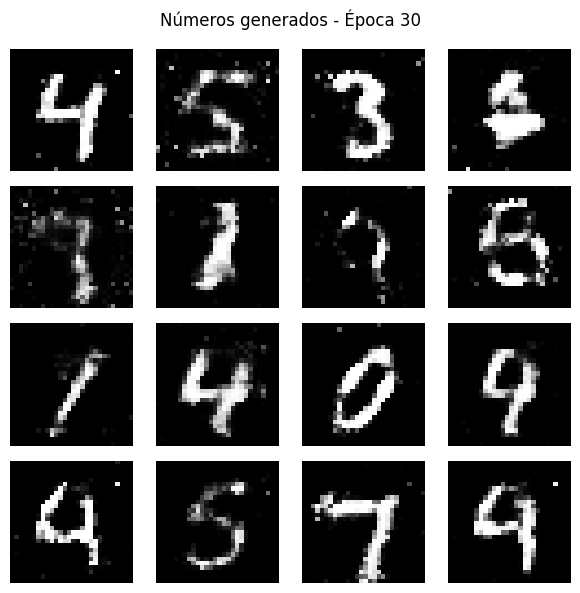

Época [31/100] Loss D: 1.1160 Loss G: 0.9715
Época [32/100] Loss D: 1.1004 Loss G: 0.9044
Época [33/100] Loss D: 1.1754 Loss G: 0.7504
Época [34/100] Loss D: 1.1669 Loss G: 0.8596
Época [35/100] Loss D: 1.0986 Loss G: 0.9794
Época [36/100] Loss D: 1.1699 Loss G: 1.2356
Época [37/100] Loss D: 1.1321 Loss G: 0.9052
Época [38/100] Loss D: 1.2198 Loss G: 0.6890
Época [39/100] Loss D: 1.3161 Loss G: 0.9296
Época [40/100] Loss D: 1.1450 Loss G: 1.1204


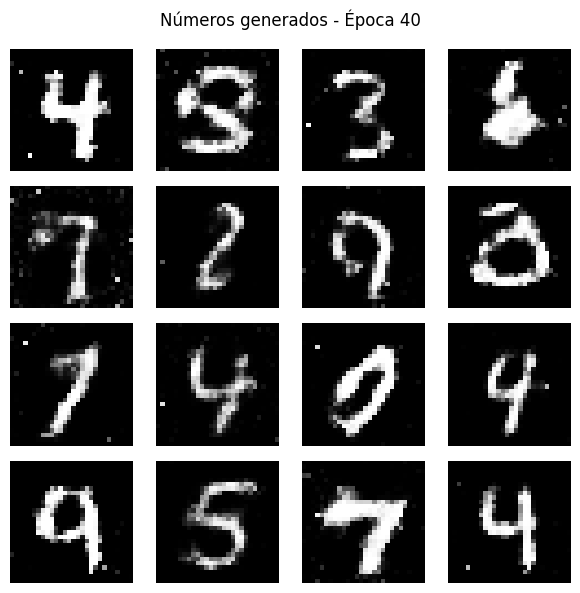

Época [41/100] Loss D: 1.2253 Loss G: 1.5204
Época [42/100] Loss D: 1.0479 Loss G: 1.0500
Época [43/100] Loss D: 1.3031 Loss G: 1.4551
Época [44/100] Loss D: 1.0703 Loss G: 0.9468
Época [45/100] Loss D: 1.2238 Loss G: 0.7863
Época [46/100] Loss D: 1.1258 Loss G: 1.0267
Época [47/100] Loss D: 1.1848 Loss G: 1.1735
Época [48/100] Loss D: 1.1517 Loss G: 1.3100
Época [49/100] Loss D: 1.1969 Loss G: 1.2680
Época [50/100] Loss D: 1.0689 Loss G: 1.2654


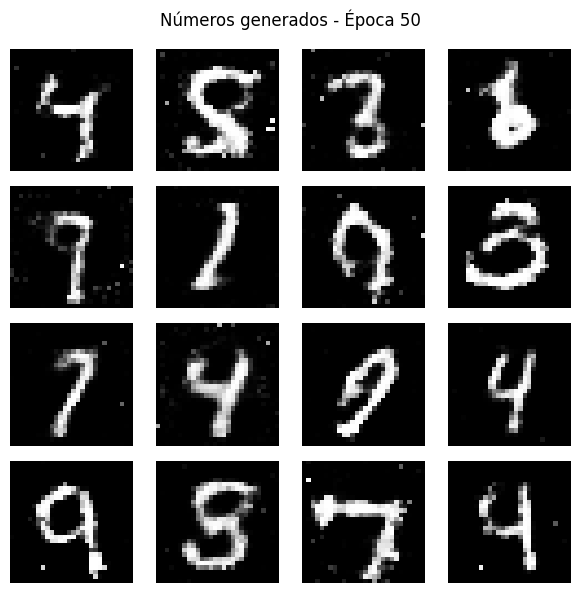

Época [51/100] Loss D: 1.0328 Loss G: 1.2529
Época [52/100] Loss D: 1.2319 Loss G: 0.6136
Época [53/100] Loss D: 1.3218 Loss G: 1.8137
Época [54/100] Loss D: 1.0940 Loss G: 1.3109
Época [55/100] Loss D: 1.0655 Loss G: 1.3269
Época [56/100] Loss D: 1.0569 Loss G: 1.0667
Época [57/100] Loss D: 1.1032 Loss G: 0.8963
Época [58/100] Loss D: 1.0494 Loss G: 1.1813
Época [59/100] Loss D: 1.0911 Loss G: 1.3924
Época [60/100] Loss D: 1.3540 Loss G: 1.7986


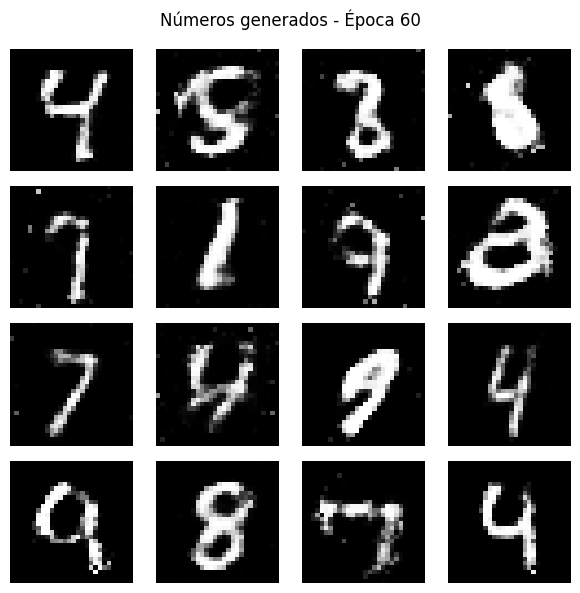

Época [61/100] Loss D: 1.2048 Loss G: 0.6831
Época [62/100] Loss D: 1.0912 Loss G: 1.0751
Época [63/100] Loss D: 1.0577 Loss G: 1.2270
Época [64/100] Loss D: 1.0428 Loss G: 1.2949
Época [65/100] Loss D: 1.1279 Loss G: 1.2185
Época [66/100] Loss D: 1.0591 Loss G: 1.3205
Época [67/100] Loss D: 1.1000 Loss G: 1.1509
Época [68/100] Loss D: 1.0999 Loss G: 0.7946
Época [69/100] Loss D: 1.1200 Loss G: 1.5647
Época [70/100] Loss D: 1.3007 Loss G: 1.8398


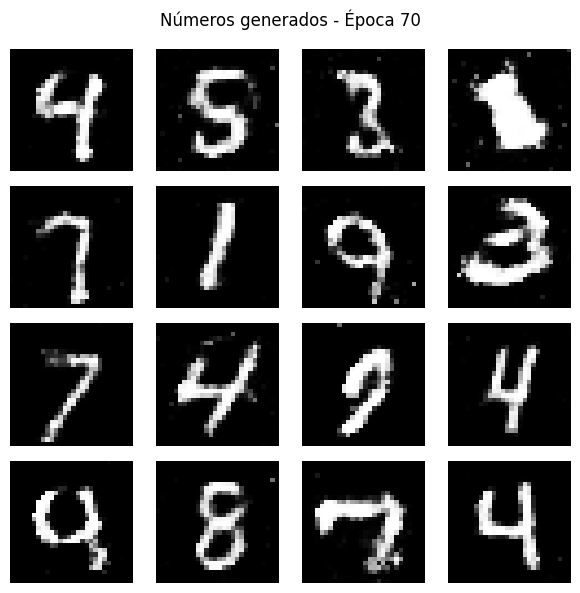

Época [71/100] Loss D: 1.1031 Loss G: 0.8076
Época [72/100] Loss D: 1.2034 Loss G: 1.5772
Época [73/100] Loss D: 1.1172 Loss G: 0.7637
Época [74/100] Loss D: 1.0665 Loss G: 0.9227
Época [75/100] Loss D: 1.1831 Loss G: 1.3075
Época [76/100] Loss D: 1.1153 Loss G: 1.2993
Época [77/100] Loss D: 1.1400 Loss G: 1.1475
Época [78/100] Loss D: 1.1896 Loss G: 0.5969
Época [79/100] Loss D: 0.8533 Loss G: 1.2313
Época [80/100] Loss D: 1.1113 Loss G: 0.7864


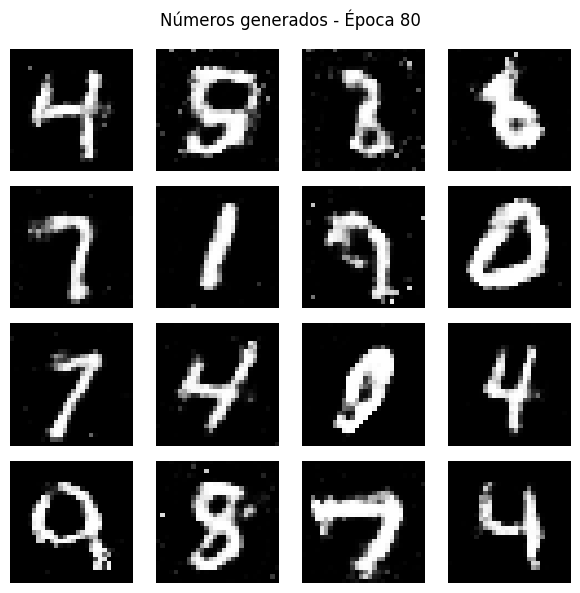

Época [81/100] Loss D: 1.0989 Loss G: 1.1489
Época [82/100] Loss D: 1.0403 Loss G: 1.1277
Época [83/100] Loss D: 1.1199 Loss G: 1.3125
Época [84/100] Loss D: 1.0350 Loss G: 1.5417
Época [85/100] Loss D: 0.9946 Loss G: 1.4124
Época [86/100] Loss D: 1.2378 Loss G: 0.7106
Época [87/100] Loss D: 1.1365 Loss G: 0.8511
Época [88/100] Loss D: 1.0225 Loss G: 1.0801
Época [89/100] Loss D: 0.9954 Loss G: 1.2116
Época [90/100] Loss D: 1.0808 Loss G: 0.7378


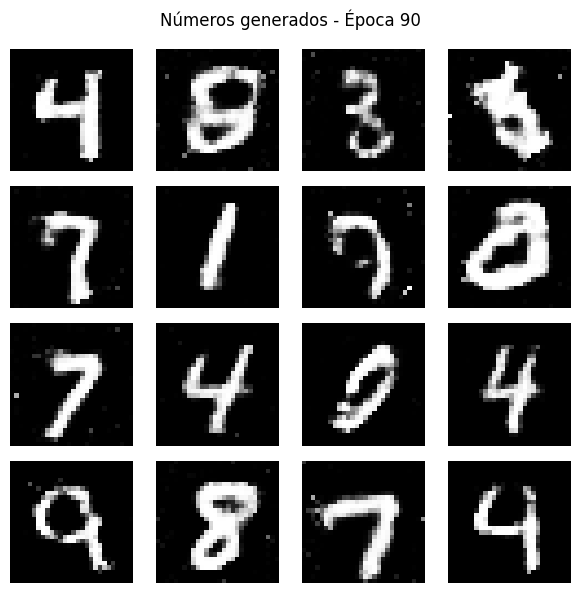

Época [91/100] Loss D: 1.0745 Loss G: 1.2239
Época [92/100] Loss D: 0.9832 Loss G: 1.0538
Época [93/100] Loss D: 1.0745 Loss G: 0.8197
Época [94/100] Loss D: 1.0454 Loss G: 0.9334
Época [95/100] Loss D: 1.0625 Loss G: 1.6394
Época [96/100] Loss D: 1.0167 Loss G: 0.9843
Época [97/100] Loss D: 1.0344 Loss G: 1.1520
Época [98/100] Loss D: 0.9542 Loss G: 1.0786
Época [99/100] Loss D: 1.1214 Loss G: 1.5167
Época [100/100] Loss D: 1.0249 Loss G: 1.5369


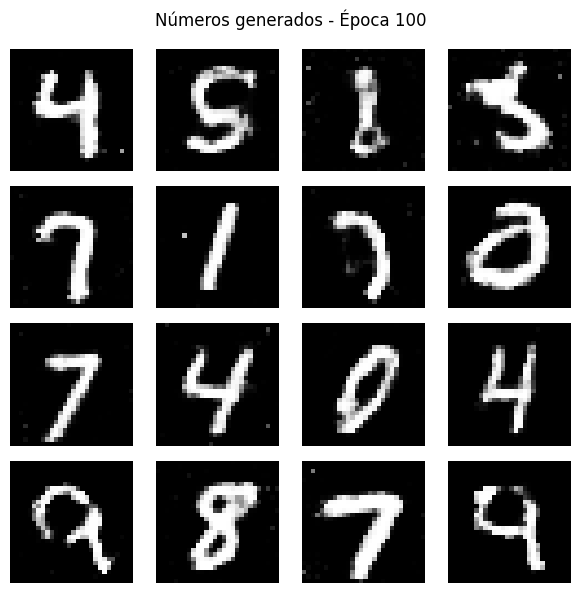


Generador guardado como:
generator_mnist.pth


In [3]:
# ============================================================
# GAN - Generación de números escritos a mano con MNIST
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Configuración
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

# Parámetros
batch_size = 128
latent_dim = 100
epochs = 100
lr = 0.0002

# ------------------------------------------------------------
# 2. Dataset MNIST
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

# ------------------------------------------------------------
# 3. GENERADOR
# ------------------------------------------------------------

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # 100 -> 256
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),

            # 256 -> 512
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            # 512 -> 1024
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),

            # 1024 -> 784
            nn.Linear(1024, 784),

            # Valores entre -1 y 1
            nn.Tanh()
        )

    def forward(self, z):

        img = self.model(z)

        # Convertimos 784 valores en una imagen 28x28
        img = img.view(-1, 1, 28, 28)

        return img


# ------------------------------------------------------------
# 4. DISCRIMINADOR
# ------------------------------------------------------------

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            # Imagen 28x28 = 784
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),

            # Probabilidad real/falso
            nn.Sigmoid()
        )

    def forward(self, img):

        img = img.view(img.size(0), -1)

        return self.model(img)


# ------------------------------------------------------------
# 5. Crear redes
# ------------------------------------------------------------

generator = Generator().to(device)
discriminator = Discriminator().to(device)

print("\nGENERADOR")
print(generator)

print("\nDISCRIMINADOR")
print(discriminator)

# ------------------------------------------------------------
# 6. Función de pérdida
# ------------------------------------------------------------

criterion = nn.BCELoss()

# ------------------------------------------------------------
# 7. Optimizadores
# ------------------------------------------------------------

optimizer_G = optim.Adam(
    generator.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    discriminator.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

# ------------------------------------------------------------
# 8. Ruido fijo para visualizar la evolución
# ------------------------------------------------------------

fixed_noise = torch.randn(
    16,
    latent_dim,
    device=device
)

# ------------------------------------------------------------
# 9. Función para mostrar números generados
# ------------------------------------------------------------

def mostrar_generados(generator, epoch):

    generator.eval()

    with torch.no_grad():

        generated = generator(fixed_noise)

    generator.train()

    generated = generated.cpu()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))

    for i, ax in enumerate(axes.flatten()):

        ax.imshow(
            generated[i].squeeze(),
            cmap="gray"
        )

        ax.axis("off")

    plt.suptitle(
        f"Números generados - Época {epoch}"
    )

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# 10. Entrenamiento
# ------------------------------------------------------------

for epoch in range(1, epochs + 1):

    for batch_idx, (real_images, _) in enumerate(dataloader):

        # ----------------------------------------------------
        # Preparar imágenes reales
        # ----------------------------------------------------

        real_images = real_images.to(device)

        batch_size_actual = real_images.size(0)

        # Etiquetas
        real_labels = torch.ones(
            batch_size_actual,
            1,
            device=device
        )

        fake_labels = torch.zeros(
            batch_size_actual,
            1,
            device=device
        )

        # ====================================================
        # ENTRENAR DISCRIMINADOR
        # ====================================================

        optimizer_D.zero_grad()

        # ----------------------------------------------------
        # Imágenes reales
        # ----------------------------------------------------

        output_real = discriminator(real_images)

        loss_real = criterion(
            output_real,
            real_labels
        )

        # ----------------------------------------------------
        # Imágenes falsas
        # ----------------------------------------------------

        noise = torch.randn(
            batch_size_actual,
            latent_dim,
            device=device
        )

        fake_images = generator(noise)

        output_fake = discriminator(
            fake_images.detach()
        )

        loss_fake = criterion(
            output_fake,
            fake_labels
        )

        # ----------------------------------------------------
        # Pérdida total del discriminador
        # ----------------------------------------------------

        loss_D = loss_real + loss_fake

        loss_D.backward()

        optimizer_D.step()

        # ====================================================
        # ENTRENAR GENERADOR
        # ====================================================

        optimizer_G.zero_grad()

        # Crear nuevo ruido
        noise = torch.randn(
            batch_size_actual,
            latent_dim,
            device=device
        )

        fake_images = generator(noise)

        output = discriminator(fake_images)

        # El Generador quiere que el Discriminador
        # piense que las imágenes son reales
        loss_G = criterion(
            output,
            real_labels
        )

        loss_G.backward()

        optimizer_G.step()

    # --------------------------------------------------------
    # Mostrar progreso
    # --------------------------------------------------------

    print(
        f"Época [{epoch}/{epochs}] "
        f"Loss D: {loss_D.item():.4f} "
        f"Loss G: {loss_G.item():.4f}"
    )

    # --------------------------------------------------------
    # Mostrar imágenes cada 10 épocas
    # --------------------------------------------------------

    if epoch == 1 or epoch % 10 == 0:

        mostrar_generados(
            generator,
            epoch
        )


# ------------------------------------------------------------
# 11. Guardar Generador
# ------------------------------------------------------------

torch.save(
    generator.state_dict(),
    "generator_mnist.pth"
)

print("\nGenerador guardado como:")
print("generator_mnist.pth")